In [1]:
%config InlineBackend.figure_formats = ['svg']
import numpy as np  # noqa
import matplotlib as mpl  # noqa
import matplotlib.pyplot as plt  # noqa
import quimb as qu  # noqa
import xyzpy as xyz  # noqa
import autoray as ar  # noqa
import cotengra as ctg  # noqa
import quimb.tensor as qtn  # noqa

mpl.style.use(xyz.get_neutral_style(draw_color="black"))

import sys

sys.path.append("..")

import simpclustlib

mpl.rcParams["font.family"] = "Inter"

/media/johnnie/Storage2TB/Sync/work/simpclust/tn-loop-cluster-expansions/figs/../simpclustlib.py:19: FutureWarning: The module 'quimb.tensor.tensor_arbgeom' is deprecated and will be removed in a future release. Most functionality can be still be accessed directly from 'quimb.tensor' instead. The actual implementations have moved to `quimb.tensor.tnag.core`.
  from quimb.tensor.tensor_arbgeom import TensorNetworkGenVector


In [2]:
color_gl = (0.8, 0.2, 0.8)

In [3]:
ds_ref_heis = (
    xyz.load_ds("../data/energy_full_heis_square_obc.h5")
    .sel(
        symm="U1",
        L=slice(None, 10),
        drop=True,
    )
    .squeeze(drop=True)
)
ds_ref_fmhb = (
    xyz.load_ds("../data/energy_full_fermi_hubbard_U8_square_obc.h5")
    .sel(
        symm="U1",
        L=slice(None, 10),
        site_charge="uniform-1",
        drop=True,
    )
    .squeeze(drop=True)
)
ds_ref_tfim = (
    xyz.load_ds("../data/energy_full_tfim_hz-3_square_obc.h5")
    .sel(
        symm="Z2",
        L=slice(None, 10),
        drop=True,
    )
    .squeeze(drop=True)
)

In [4]:
simpclustlib.estimate_full_stats_into_ds(ds_ref_heis, mode="wynn")
simpclustlib.estimate_full_stats_into_ds(ds_ref_fmhb, mode="wynn")
simpclustlib.estimate_full_stats_into_ds(ds_ref_tfim, mode="wynn")

In [5]:
ds_glx_heis = xyz.load_ds(
    "../data/energy_gloop_expand_heis_square_obc.h5"
).squeeze(drop=True)
ds_glx_fmhb = xyz.load_ds(
    "../data/energy_gloop_expand_fermi_hubbard_U8_square_obc.h5"
).squeeze(drop=True)
ds_glx_tfim = xyz.load_ds(
    "../data/energy_gloop_expand_tfim_hz-3_square_obc.h5"
).squeeze(drop=True)

ds_glx_heis["max_size"] = ds_glx_heis["max_size"].clip(2, None)
ds_glx_fmhb["max_size"] = ds_glx_fmhb["max_size"].clip(2, None)
ds_glx_tfim["max_size"] = ds_glx_tfim["max_size"].clip(2, None)

In [6]:
wynn_mode = "wynn"
yvar = "energy_gloop_expand"

In [7]:
def datarange(x, last=None):
    if last is not None:
        x = x[-last:]
    return np.max(x) - np.min(x)

In [8]:
color_gl0 = (0.8, 0.2, 0.8)
color_gl2 = (0.6, 0.4, 0.9)
color_gl4 = (0.4, 0.6, 1.0)
color_ref = (0.5, 0.8, 0.2)
markers = ["X", "P", "."]

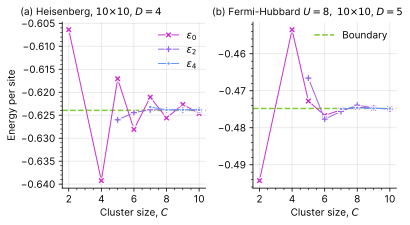

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), gridspec_kw=dict(wspace=0.33))


ax = axs[0]
(model, geom, L, D) = ("heis", "square_obc", 10, 4)

ds_glx = xyz.load_ds(f"../data/energy_gloop_expand_{model}_{geom}.h5").squeeze(
    drop=True
)
ds_glx["max_size"] = ds_glx["max_size"].clip(2, None)

x = ds_glx["max_size"].values
y = ds_glx[yvar].sel(L=L, D=D).values

mask = np.isfinite(y)
x = x[mask]
y = y[mask]

wynns = simpclustlib.compute_wynn_eps(y, mode=wynn_mode)

num_wynns = max(k for k in wynns if k % 2 == 0) // 2 + 1
num_wynns = min(num_wynns, 3)

for i in range(num_wynns):
    ax.plot(
        x[2 * i :],
        wynns[2 * i],
        markersize=7,
        marker=markers[i],
        markeredgecolor="white",
        label=f"$\\epsilon_{2 * i}$",
        color=[color_gl0, color_gl2, color_gl4][i],
        linewidth=1,
        # color=(0, .2, .6),
        # linestyle="--",
    )

sel = dict(L=L, D=D, symm="U1")
ds_ref = (
    xyz.load_ds(f"../data/energy_full_{model}_{geom}.h5")
    .sel(
        sel,
        drop=True,
    )
    .squeeze(drop=True)
)

simpclustlib.estimate_full_stats_into_ds(ds_ref, mode="wynn")
ref = ds_ref["energy_estimate"].item()

# ax.set_ylim(-0.629, -0.6165)

ax.axhline(
    ref,
    linewidth=1.5,
    linestyle="--",
    color=color_ref,
    zorder=-10,
)

ax.legend()
ax.set_xlabel("Cluster size, $C$")
ax.set_xticks([2, 4, 6, 8, 10])
ax.set_ylabel("Energy per site")
ax.text(
    0.2,
    1.03,
    f"(a) Heisenberg, ${L}{{\\times}}{L}$, $D{{=}}{D}$",
    fontsize=10,
    transform=ax.transAxes,
    ha="center",
    va="bottom",
)


ax = axs[1]
(model, geom, L, D) = ("fermi_hubbard_U8", "square_obc", 10, 5)

ds_glx = xyz.load_ds(f"../data/energy_gloop_expand_{model}_{geom}.h5").squeeze(
    drop=True
)
ds_glx["max_size"] = ds_glx["max_size"].clip(2, None)
x = ds_glx["max_size"].values
y = ds_glx[yvar].sel(L=L, D=D).values

mask = np.isfinite(y)
x = x[mask]
y = y[mask]

wynns = simpclustlib.compute_wynn_eps(y, mode=wynn_mode)

num_wynns = max(k for k in wynns if k % 2 == 0) // 2 + 1
num_wynns = min(num_wynns, 3)

for i in range(num_wynns):
    ax.plot(
        x[2 * i :],
        wynns[2 * i],
        markersize=7,
        marker=markers[i],
        markeredgecolor="white",
        # label=f"$\\epsilon_{2*i}$",
        color=[color_gl0, color_gl2, color_gl4][i],
        linewidth=1,
        # color=(0, .2, .6),
        # linestyle="--",
    )

sel = dict(L=L, D=D, symm="U1", site_charge="uniform-1")
ds_ref = (
    xyz.load_ds(f"../data/energy_full_{model}_{geom}.h5")
    .sel(
        sel,
        drop=True,
    )
    .squeeze(drop=True)
)

simpclustlib.estimate_full_stats_into_ds(ds_ref, mode="wynn")
ref = ds_ref["energy_estimate"].item()

# ax.set_ylim(-0.481, -0.4661)

ax.axhline(
    ref,
    linewidth=1.5,
    linestyle="--",
    color=color_ref,
    zorder=-10,
    label="Boundary",
)

ax.legend(loc="upper right")
ax.set_xlabel("Cluster size, $C$")
ax.set_xticks([2, 4, 6, 8, 10])
ax.text(
    0.38,
    1.03,
    f"(b) Fermi-Hubbard $U{{=}}8,$ ${L}{{\\times}}{L}$, $D{{=}}{D}$",
    fontsize=10,
    transform=ax.transAxes,
    ha="center",
    va="bottom",
)
# ax.text(
#     0.2, 0.06,
#     f"(b) Fermi-Hubbard\n$U{{=}}8,$ ${L}{{\\times}}{L}$, $D{{=}}{D}$",
#     fontsize=10, transform=ax.transAxes, ha="left", va="bottom"
# )

plt.show()
plt.close()

In [10]:
fig.savefig("fig-wynn-extrapolation-example.png", dpi=300, bbox_inches="tight")